# Multi-Run Evaluation & Comparison Notebook

Loads multiple trained runs, rebuilds each environment from its saved config, runs a greedy simulation (ε=0) for each, and produces side-by-side comparison plots and a summary table.

In [19]:
# ── Runs to compare ────────────────────────────────────────────────────────────
# Each entry is (run_directory, display_label).
# Label defaults to the directory basename if set to None.
RUNS = [
    ("training_results/run_20260329_182736", "1 agent per workflow"),
    ("training_results/run_20260329_183555", "1 agent for all workflows"),
]

In [20]:
import sys
import json
import pickle
import random
import warnings
from pathlib import Path
from itertools import product

import numpy as np
import matplotlib.pyplot as plt
import yaml

sys.path.insert(0, str(Path(".").resolve()))

from simulator.application import Application
from simulator.infrastructure import Node
from simulator.simulation import Simulation
from agents.agents import QLearningAgent

## Helper functions

In [21]:
def _normalize_control(name):
    n = str(name).strip().lower()
    if n in ("scaling", "replicas", "cpu"):
        return "cpu"
    if n in ("migration", "placement", "node"):
        return "node"
    raise ValueError(f"Unknown control: {name}")


def _parse_service_token(token, sids):
    raw = int(str(token).strip().lower().lstrip("s"))
    if 0 in sids and (raw - 1) in sids:
        return raw - 1
    return raw if raw in sids else raw - 1


def _build_action_space(responsibilities, node_pool, cpu_actions):
    dims = [(sid, ctrl, list(cpu_actions) if ctrl == "cpu" else list(node_pool))
            for sid, ctrl in responsibilities]
    if not dims:
        return [{}]
    space = []
    for combo in product(*[opts for _, _, opts in dims]):
        action = {}
        for (sid, ctrl, _), val in zip(dims, combo):
            action.setdefault(sid, {})[ctrl] = val
        space.append(action)
    return space


def _make_get_state(responsibilities, cpu_cap=20):
    scope = sorted({sid for sid, _ in responsibilities})
    def _get_state(self, obs):
        queues = obs.get("service_queues", [])
        cpus   = obs.get("service_cpus", [])
        state  = []
        for sid in scope:
            q = int(queues[sid])
            state.append(0 if q == 0 else 1 if q <= 4 else 2)
        for sid in scope:
            state.append(min(int(cpus[sid]), cpu_cap))
        return tuple(state)
    return _get_state


def _make_reward(responsibilities, workflow_scope, reward_cpu_w, reward_lat_w, lat_tgt):
    scope   = sorted({sid for sid, _ in responsibilities})
    total_w = reward_cpu_w + reward_lat_w
    cpu_w   = reward_cpu_w / total_w if total_w > 0 else 0.5
    lat_w   = reward_lat_w / total_w if total_w > 0 else 0.5
    lat_tgt = max(float(lat_tgt), 1e-12)
    def _reward(self, obs):
        viol_rates = obs.get("workflow_violation_rates", [])
        e2e_means  = obs.get("workflow_e2e_means", [])
        node_ids   = obs.get("service_node_ids", [])
        node_cpu   = obs.get("node_cpu_usage_pct", {})
        lat_viols  = []
        for wid in workflow_scope:
            if wid < len(viol_rates):
                lat_viols.append(min(1.0, max(0.0, float(viol_rates[wid]))))
            else:
                e2e = float(e2e_means[wid]) if wid < len(e2e_means) else 0.0
                lat_viols.append(min(1.0, max(0.0, (e2e - lat_tgt) / lat_tgt)))
        mean_lat = float(np.mean(lat_viols)) if lat_viols else 0.0
        nscope = sorted({node_ids[sid] for sid in scope}) if scope else []
        mean_cpu = float(np.mean([min(1.0, max(0.0, float(node_cpu.get(nid, 0.0)))) for nid in nscope])) if nscope else 0.0
        return 1.0 - (cpu_w * mean_cpu + lat_w * mean_lat)
    return _reward

## EvalDispatcher

In [22]:
class EvalDispatcher:
    """Greedy dispatcher (epsilon=0) that records per-eval-window metrics."""

    def __init__(self, service_ids, global_agents, nodes, cpu_max):
        self.service_ids   = list(service_ids)
        self.global_agents = global_agents
        self.nodes         = nodes
        self.cpu_max       = cpu_max
        self._reset_state()

    def _reset_state(self):
        self._eval_counter            = 0
        self._planned_actions         = {}
        self._last_node_metric_idx    = {n.id: 0 for n in self.nodes}
        self._sim_time                = 0.0
        self.eval_times               = []
        self.svc_queue_hist           = {sid: [] for sid in self.service_ids}
        self.svc_thread_hist          = {sid: [] for sid in self.service_ids}
        self.svc_running_hist         = {sid: [] for sid in self.service_ids}
        self.wf_violation_hist        = {}
        self.wf_latency_hist          = {}
        self.wf_success_hist          = {}
        self.node_cpu_hist            = {n.id: [] for n in self.nodes}
        self.agent_reward_hist        = {item["name"]: [] for item in self.global_agents}
        for item in self.global_agents:
            item["agent"].reset_environment()

    def _build_observations(self, accumulated, instant):
        svc_now  = instant["services"]
        queues   = [s["queue_size"] for s in svc_now]
        threads  = [s["threads"]    for s in svc_now]
        node_ids = [s["node_id"]    for s in svc_now]
        node_cpu_pct = {}
        for node in self.nodes:
            arr   = np.array(node.cpu_metric, dtype=float)
            start = int(self._last_node_metric_idx.get(node.id, 0))
            seg   = arr[start:] if start < arr.size else np.array([], dtype=float)
            avg   = float(np.mean(seg)) if seg.size > 0 else 0.0
            node_cpu_pct[node.id] = min(1.0, max(0.0, avg / max(self.cpu_max, 1e-12)))
            self._last_node_metric_idx[node.id] = arr.size
        return {
            "service_queues"          : queues,
            "service_cpus"            : threads,
            "service_node_ids"        : node_ids,
            "workflow_e2e_means"      : accumulated["workflows"].get("e2e_latencies", []),
            "workflow_violation_rates": accumulated["workflows"].get("violation_rates", []),
            "node_cpu_usage_pct"      : node_cpu_pct,
            "avg_success_rate"        : accumulated["workflows"]["avg_success_rate"],
        }

    def _capture(self, accumulated, instant, obs):
        self._sim_time += float(accumulated.get("elapsed", 0.0))
        self.eval_times.append(self._sim_time)
        for s_info in instant["services"]:
            sid = s_info["service_id"]
            self.svc_queue_hist[sid].append(s_info["queue_size"])
            self.svc_thread_hist[sid].append(s_info["threads"])
            self.svc_running_hist[sid].append(s_info["running_tasks"])
        viol_list = accumulated["workflows"].get("violation_rates", [])
        lat_list  = accumulated["workflows"].get("e2e_latencies", [])
        sr_list   = accumulated["workflows"].get("success_rate", [])
        for wid, (vr, lat, sr) in enumerate(zip(viol_list, lat_list, sr_list)):
            self.wf_violation_hist.setdefault(wid, []).append(vr * 100.0)
            self.wf_latency_hist.setdefault(wid, []).append(lat)
            self.wf_success_hist.setdefault(wid, []).append(sr)
        for nid, pct in obs["node_cpu_usage_pct"].items():
            self.node_cpu_hist[nid].append(pct * 100.0)
        for item in self.global_agents:
            r = item["agent"].rewards[-1] if item["agent"].rewards else 0.0
            self.agent_reward_hist[item["name"]].append(r)

    def _compute_plan(self, accumulated, instant):
        obs      = self._build_observations(accumulated, instant)
        combined = {sid: {} for sid in self.service_ids}
        for item in self.global_agents:
            idx = int(item["agent"].step(obs))
            idx = max(0, min(idx, len(item["action_space"]) - 1))
            for sid, act in item["action_space"][idx].items():
                combined[sid].update(act)
        self._planned_actions = combined
        self._capture(accumulated, instant, obs)

    def on_eval(self, service_idx, service, accumulated, instant):
        if self._eval_counter % len(self.service_ids) == 0:
            self._compute_plan(accumulated, instant)
        self._eval_counter += 1
        action = self._planned_actions.get(service.id, {})
        return action if action else None

## Run evaluations

In [23]:
results = []  # list of dicts, one per run

for run_dir_str, label in RUNS:
    run_dir = Path(run_dir_str)
    if label is None:
        label = run_dir.name

    print(f"\n{'='*60}")
    print(f"  Run: {label}  ({run_dir})")
    print(f"{'='*60}")

    # ── Load artifacts ─────────────────────────────────────────────────────────
    try:
        with open(run_dir / "config.yaml") as f:
            config = yaml.safe_load(f)
        with open(run_dir / "metadata.json") as f:
            metadata = json.load(f)
        with open(run_dir / "qtables.pkl", "rb") as f:
            qtables = pickle.load(f)
    except Exception as e:
        print(f"  WARNING: could not load run '{label}': {e}  — skipping.")
        continue

    print(f"  Created : {metadata['created_at']}")
    print(f"  Episodes: {metadata['training']['n_episodes']}  "
          f"best_reward={metadata['training']['best_episode_reward']:.2f}")

    # ── Parse config ───────────────────────────────────────────────────────────
    APP_TOPOLOGY = config.get("topology", {})
    for wf in APP_TOPOLOGY.get("workflows", []):
        wf["edges"] = [tuple(e) for e in wf.get("edges", [])]

    infra_cfg     = config.get("infrastructure", {})
    N_NODES       = infra_cfg.get("n_nodes", 3)
    CPU_MAX       = infra_cfg.get("cpu_max", 4)
    RAM           = infra_cfg.get("ram", 8)
    FREQ          = infra_cfg.get("freq", 1000)

    sim_cfg       = config.get("simulation", {})
    ITERATIONS    = sim_cfg.get("iterations", 500)
    TIMEOUT       = sim_cfg.get("timeout", 600000)
    EVAL_INTERVAL = sim_cfg.get("eval_interval", 10.0)
    SEED          = sim_cfg.get("seed", 42)

    rl_cfg        = config.get("rl", {})
    ALPHA         = rl_cfg.get("alpha", 0.1)
    GAMMA         = rl_cfg.get("gamma", 0.9)

    ctrl_cfg      = config.get("control", {})
    AGENT_CONTROLS_REPLICAS   = ctrl_cfg.get("agent_controls_replicas", True)
    AGENT_CONTROLS_PLACEMENT  = ctrl_cfg.get("agent_controls_placement", False)
    AGENT_CONTROL_ASSIGNMENTS = ctrl_cfg.get("agent_control_assignments", {})

    reward_cfg        = config.get("reward", {})
    E2E_LAT_TARGET    = reward_cfg.get("e2e_lat_target", 4.0)
    REWARD_CPU_WEIGHT = reward_cfg.get("reward_cpu_weight", 0.5)
    REWARD_LAT_WEIGHT = reward_cfg.get("reward_lat_viol_weight", 0.5)

    np.random.seed(SEED)
    random.seed(SEED)

    # ── Rebuild app and infrastructure ─────────────────────────────────────────
    app   = Application(topology=APP_TOPOLOGY)
    nodes = [Node(i, CPU_MAX, RAM, FREQ) for i in range(N_NODES)]

    initial_service_map = {s.id: nodes[s.id % N_NODES] for s in app.services}
    app.deploy_services(initial_service_map)
    for s in app.services:
        s.threads = CPU_MAX
    app.reset()

    service_ids = [s.id for s in app.services]

    # ── Build agent specs ──────────────────────────────────────────────────────
    service_to_wf = {}
    for wf in app.workflows:
        for task_node in wf.nodes:
            sid = int(app.task_graph.nodes[task_node]["subset"])
            service_to_wf.setdefault(sid, set()).add(wf.id)
    service_to_wf = {k: sorted(v) for k, v in service_to_wf.items()}

    by_agent = {}
    for key, agent_name in AGENT_CONTROL_ASSIGNMENTS.items():
        parts = str(key).split(".", 1)
        sid   = _parse_service_token(parts[0], service_ids)
        ctrl  = _normalize_control(parts[1])
        by_agent.setdefault(str(agent_name).strip(), set()).add((sid, ctrl))

    agent_specs = []
    for aname in sorted(by_agent.keys()):
        resp         = sorted(by_agent[aname])
        action_space = _build_action_space(resp, [n.id for n in nodes], range(1, CPU_MAX + 1))
        s_scope      = {sid for sid, _ in resp}
        wf_scope     = sorted({wid for sid in s_scope for wid in service_to_wf.get(sid, [])})
        agent_specs.append({"name": aname, "responsibilities": resp,
                             "action_space": action_space, "workflow_scope": wf_scope})

    # ── Instantiate agents with epsilon=0 and load Q-tables ───────────────────
    global_agents = []
    for spec in agent_specs:
        agent = QLearningAgent(epsilon=0.0, alpha=ALPHA, gamma=GAMMA,
                               actions=list(range(len(spec["action_space"]))))
        agent.get_state = _make_get_state(spec["responsibilities"]).__get__(agent, QLearningAgent)
        agent.reward    = _make_reward(
            spec["responsibilities"], spec["workflow_scope"],
            REWARD_CPU_WEIGHT, REWARD_LAT_WEIGHT, E2E_LAT_TARGET
        ).__get__(agent, QLearningAgent)
        if spec["name"] in qtables:
            agent.q_table = qtables[spec["name"]]
            print(f"  {spec['name']}: loaded Q-table ({len(agent.q_table)} states)")
        else:
            print(f"  WARNING: no saved Q-table for agent '{spec['name']}'")
        global_agents.append({
            "name": spec["name"], "responsibilities": spec["responsibilities"],
            "workflow_scope": spec["workflow_scope"],
            "action_space": spec["action_space"], "agent": agent,
        })

    # ── Reset and run simulation ───────────────────────────────────────────────
    for s in app.services:
        s.node    = initial_service_map[s.id]
        s.threads = CPU_MAX
    app.reset()
    for node in nodes:
        node.reset()

    dispatcher  = EvalDispatcher(service_ids, global_agents, nodes, CPU_MAX)
    dispatchers = {sid: dispatcher for sid in service_ids}

    sim = Simulation(
        [app], [],
        ITERATIONS,
        step_size=ITERATIONS,
        alloc_step_size=1,
        timeout=TIMEOUT,
        eval_interval=EVAL_INTERVAL,
        latency_target=E2E_LAT_TARGET,
    )
    sim.run(agents=dispatchers)
    print(f"  Simulation ended at t={sim.t:.1f}s  |  {len(sim.history)} traces")

    # ── Parse history ──────────────────────────────────────────────────────────
    task_to_wf   = {}
    for wf in app.workflows:
        for tid in wf.nodes:
            task_to_wf[int(tid)] = int(wf.id)
    wf_root_task = {int(wf.id): int(wf.initial_task.id) for wf in app.workflows}

    per_wf_latencies  = {wf.id: [] for wf in app.workflows}
    per_wf_arrivals   = {wf.id: [] for wf in app.workflows}
    per_wf_violations = {wf.id: [] for wf in app.workflows}
    total_req = total_viol = total_timeout = 0

    for trace_data in sim.history.values():
        status    = int(trace_data.get("status", -1))
        task_keys = [k for k in trace_data if k != "status"]
        if not task_keys:
            continue
        wf_id = next((task_to_wf.get(int(k)) for k in task_keys
                      if task_to_wf.get(int(k)) is not None), None)
        if wf_id is None:
            continue
        root_times = trace_data.get(wf_root_task.get(wf_id))
        if root_times is None or len(root_times) < 2:
            continue
        arrival = float(root_times[0])
        per_wf_arrivals[wf_id].append(arrival)
        if status == 1:
            e2e      = float(root_times[-1] - root_times[0])
            violated = e2e > E2E_LAT_TARGET
            per_wf_latencies[wf_id].append(e2e)
            per_wf_violations[wf_id].append(int(violated))
            total_req  += 1
            total_viol += int(violated)
        elif status == 2:
            total_timeout += 1

    completed = sum(1 for v in sim.history.values() if v.get("status") == 1)
    total_tr  = len(sim.history)

    print(f"  Completed: {completed}/{total_tr} ({100*completed/max(total_tr,1):.1f}%)  "
          f"Timeouts: {total_timeout}  Violations: {total_viol}")

    # ── Store results ──────────────────────────────────────────────────────────
    results.append({
        "label"             : label,
        "metadata"          : metadata,
        "config"            : config,
        "app"               : app,
        "nodes"             : nodes,
        "CPU_MAX"           : CPU_MAX,
        "E2E_LAT_TARGET"    : E2E_LAT_TARGET,
        "dispatcher"        : dispatcher,
        "global_agents"     : global_agents,
        "total_tr"          : total_tr,
        "completed"         : completed,
        "total_timeout"     : total_timeout,
        "total_req"         : total_req,
        "total_viol"        : total_viol,
        "per_wf_latencies"  : per_wf_latencies,
        "per_wf_arrivals"   : per_wf_arrivals,
        "per_wf_violations" : per_wf_violations,
    })

print(f"\nLoaded {len(results)} run(s).")


  Run: 1 agent per workflow  (training_results/run_20260329_182736)
  Created : 20260329_182736
  Episodes: 1000  best_reward=8.45
Services: 4
Tasktrees: 2
[0, 1]
[2, 3]
Labels: {0: 0, 1: 1, 2: 2, 3: 3}
  agent1: loaded Q-table (181 states)
  agent2: loaded Q-table (249 states)
  Simulation ended at t=70.0s  |  166 traces
  Completed: 106/166 (63.9%)  Timeouts: 0  Violations: 50

  Run: 1 agent for all workflows  (training_results/run_20260329_183555)
  Created : 20260329_183555
  Episodes: 1000  best_reward=4.43
Services: 4
Tasktrees: 2
[0, 1]
[2, 3]
Labels: {0: 0, 1: 1, 2: 2, 3: 3}
  agent1: loaded Q-table (2372 states)
  Simulation ended at t=67.3s  |  157 traces
  Completed: 110/157 (70.1%)  Timeouts: 0  Violations: 66

Loaded 2 run(s).


## Summary table

In [24]:
sep = "-" * 100
hdr = f"{'Run':<28} {'Episodes':>9} {'BestRew':>9} {'Total':>7} {'Done%':>6} {'Timeout%':>9} {'Viol%':>7}"
print(sep)
print(hdr)
print(sep)
for r in results:
    pct_done    = 100 * r["completed"]     / max(r["total_tr"], 1)
    pct_timeout = 100 * r["total_timeout"] / max(r["total_tr"], 1)
    pct_viol    = 100 * r["total_viol"]    / max(r["total_req"], 1)
    print(f"{r['label']:<28} {r['metadata']['training']['n_episodes']:>9} "
          f"{r['metadata']['training']['best_episode_reward']:>9.2f} "
          f"{r['total_tr']:>7} {pct_done:>6.1f} {pct_timeout:>9.1f} {pct_viol:>7.1f}")
print(sep)

# Per-workflow breakdown
print()
all_wf_ids = sorted({wid for r in results for wid in r["per_wf_latencies"]})
for wid in all_wf_ids:
    print(f"  Workflow {wid}:")
    for r in results:
        lats  = r["per_wf_latencies"].get(wid, [])
        viols = r["per_wf_violations"].get(wid, [])
        if lats:
            print(f"    {r['label']:<26}  n={len(lats):>4}  "
                  f"avg={np.mean(lats):.3f}s  p50={np.median(lats):.3f}s  "
                  f"p95={np.percentile(lats,95):.3f}s  "
                  f"viol={sum(viols)} ({100*np.mean(viols):.1f}%)")
        else:
            print(f"    {r['label']:<26}  no completed requests")
    print()

----------------------------------------------------------------------------------------------------
Run                           Episodes   BestRew   Total  Done%  Timeout%   Viol%
----------------------------------------------------------------------------------------------------
1 agent per workflow              1000      8.45     166   63.9       0.0    47.2
1 agent for all workflows         1000      4.43     157   70.1       0.0    60.0
----------------------------------------------------------------------------------------------------

  Workflow 0:
    1 agent per workflow        n=  51  avg=9.435s  p50=7.520s  p95=21.812s  viol=24 (47.1%)
    1 agent for all workflows   n=  58  avg=9.062s  p50=8.294s  p95=16.202s  viol=31 (53.4%)

  Workflow 1:
    1 agent per workflow        n=  55  avg=8.988s  p50=6.452s  p95=17.838s  viol=26 (47.3%)
    1 agent for all workflows   n=  52  avg=10.116s  p50=12.495s  p95=15.351s  viol=35 (67.3%)



## Plot 1 — Completion / Timeout / Violation rates (bar chart)

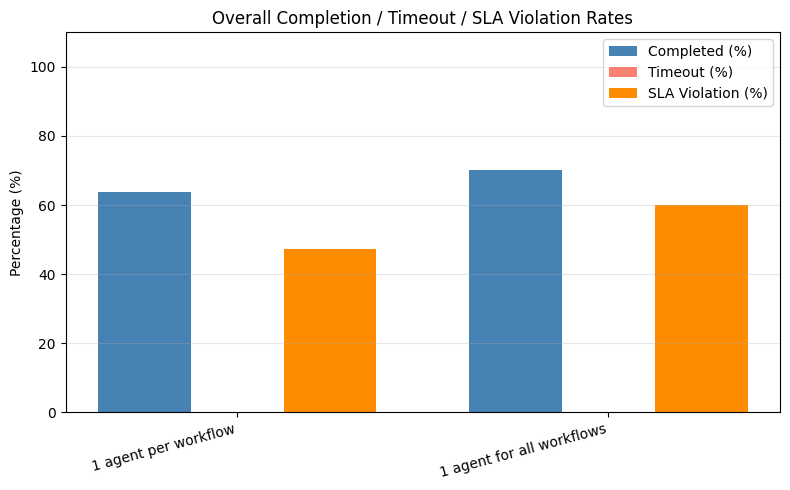

In [25]:
colors  = plt.cm.tab10.colors
labels  = [r["label"] for r in results]
x       = np.arange(len(labels))
width   = 0.25

pct_done    = [100 * r["completed"]     / max(r["total_tr"], 1) for r in results]
pct_timeout = [100 * r["total_timeout"] / max(r["total_tr"], 1) for r in results]
pct_viol    = [100 * r["total_viol"]    / max(r["total_req"], 1) for r in results]

fig, ax = plt.subplots(figsize=(max(8, 3 * len(results)), 5))
ax.bar(x - width, pct_done,    width, label="Completed (%)",        color="steelblue")
ax.bar(x,         pct_timeout, width, label="Timeout (%)",          color="salmon")
ax.bar(x + width, pct_viol,    width, label="SLA Violation (%)",    color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Percentage (%)")
ax.set_title("Overall Completion / Timeout / SLA Violation Rates")
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Plot 2 — E2E latency distribution (box plot, grouped by workflow)

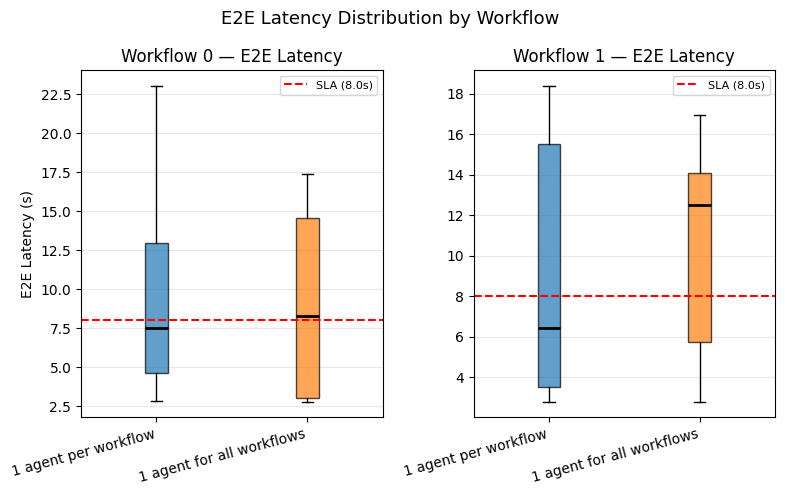

In [26]:
all_wf_ids = sorted({wid for r in results for wid in r["per_wf_latencies"]})
n_wf       = len(all_wf_ids)
n_runs     = len(results)

fig, axes = plt.subplots(1, n_wf, figsize=(max(6, 4 * n_wf), 5), squeeze=False)

for col, wid in enumerate(all_wf_ids):
    ax   = axes[0][col]
    data = [r["per_wf_latencies"].get(wid, []) for r in results]
    data = [d if d else [np.nan] for d in data]
    bp   = ax.boxplot(data, labels=labels, patch_artist=True,
                      medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    lat_tgt = results[0]["E2E_LAT_TARGET"] if results else 4.0
    ax.axhline(lat_tgt, color="red", linestyle="--",
               linewidth=1.5, label=f"SLA ({lat_tgt}s)")
    ax.set_title(f"Workflow {wid} — E2E Latency")
    ax.set_ylabel("E2E Latency (s)" if col == 0 else "")
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("E2E Latency Distribution by Workflow", fontsize=13)
plt.tight_layout()
plt.show()

## Plot 3 — SLA violation rate over simulation time

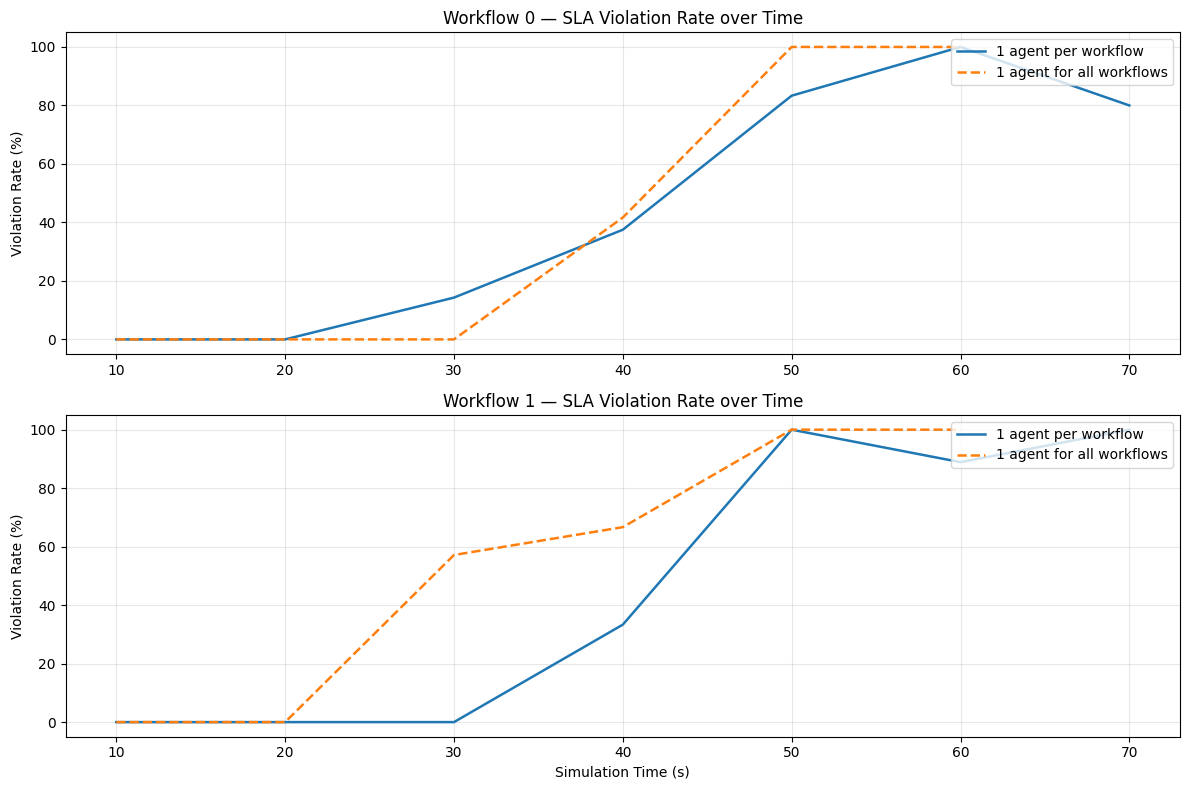

In [27]:
all_wf_ids = sorted({wid for r in results
                     for wid in r["dispatcher"].wf_violation_hist})
n_wf   = len(all_wf_ids)
styles = ["-", "--", "-.", ":"]

fig, axes = plt.subplots(n_wf, 1, figsize=(12, 4 * n_wf), sharex=False, squeeze=False)

for row, wid in enumerate(all_wf_ids):
    ax = axes[row][0]
    for i, r in enumerate(results):
        hist = r["dispatcher"].wf_violation_hist.get(wid)
        if not hist:
            continue
        t = r["dispatcher"].eval_times[:len(hist)]
        ax.plot(t, hist, color=colors[i % len(colors)],
                linestyle=styles[i % len(styles)],
                label=r["label"], linewidth=1.8)
    ax.set_ylabel("Violation Rate (%)")
    ax.set_title(f"Workflow {wid} — SLA Violation Rate over Time")
    ax.set_ylim(-5, 105)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1][0].set_xlabel("Simulation Time (s)")
plt.tight_layout()
plt.show()

## Plot 4 — Average E2E latency over simulation time

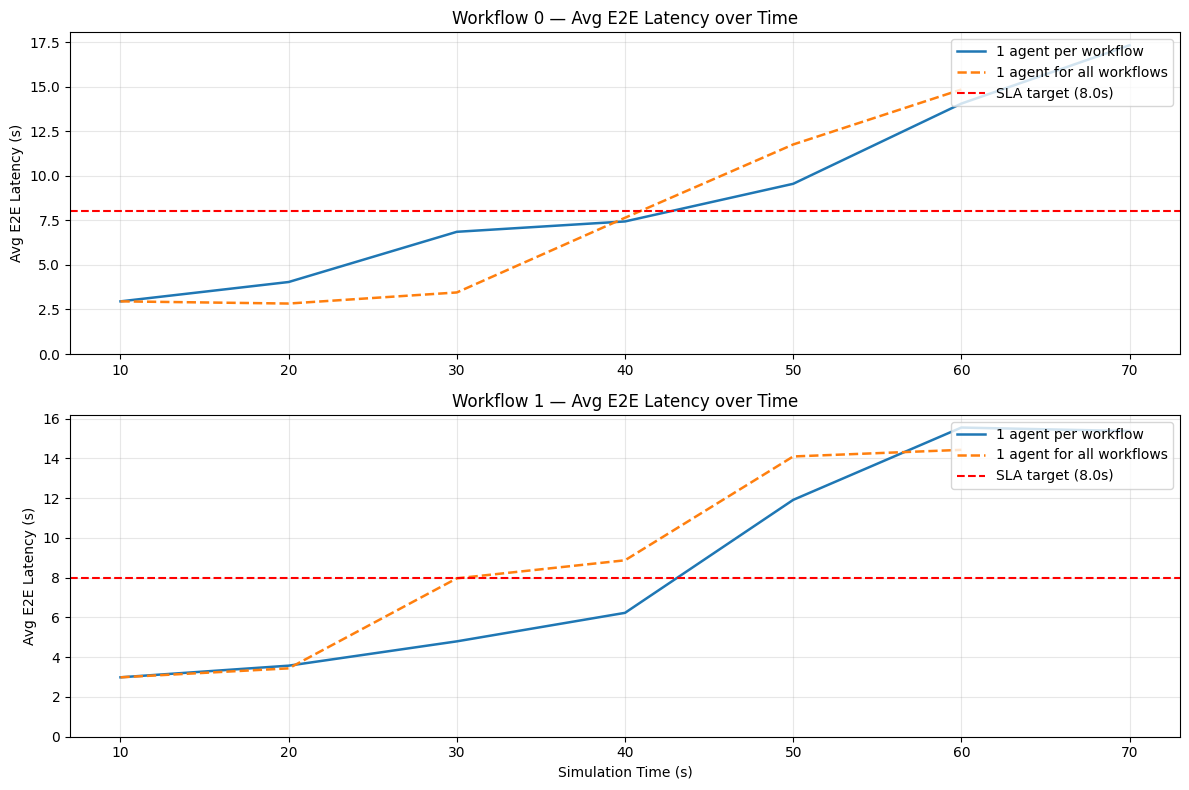

In [28]:
all_wf_ids = sorted({wid for r in results
                     for wid in r["dispatcher"].wf_latency_hist})
n_wf   = len(all_wf_ids)
styles = ["-", "--", "-.", ":"]

fig, axes = plt.subplots(n_wf, 1, figsize=(12, 4 * n_wf), sharex=False, squeeze=False)

for row, wid in enumerate(all_wf_ids):
    ax = axes[row][0]
    for i, r in enumerate(results):
        hist = r["dispatcher"].wf_latency_hist.get(wid)
        if not hist:
            continue
        t = r["dispatcher"].eval_times[:len(hist)]
        ax.plot(t, hist, color=colors[i % len(colors)],
                linestyle=styles[i % len(styles)],
                label=r["label"], linewidth=1.8)
    lat_tgt = results[0]["E2E_LAT_TARGET"] if results else 4.0
    ax.axhline(lat_tgt, color="red", linestyle="--",
               linewidth=1.5, label=f"SLA target ({lat_tgt}s)")
    ax.set_ylabel("Avg E2E Latency (s)")
    ax.set_title(f"Workflow {wid} — Avg E2E Latency over Time")
    ax.set_ylim(bottom=0)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1][0].set_xlabel("Simulation Time (s)")
plt.tight_layout()
plt.show()

## Plot 5 — Average node CPU utilisation over simulation time

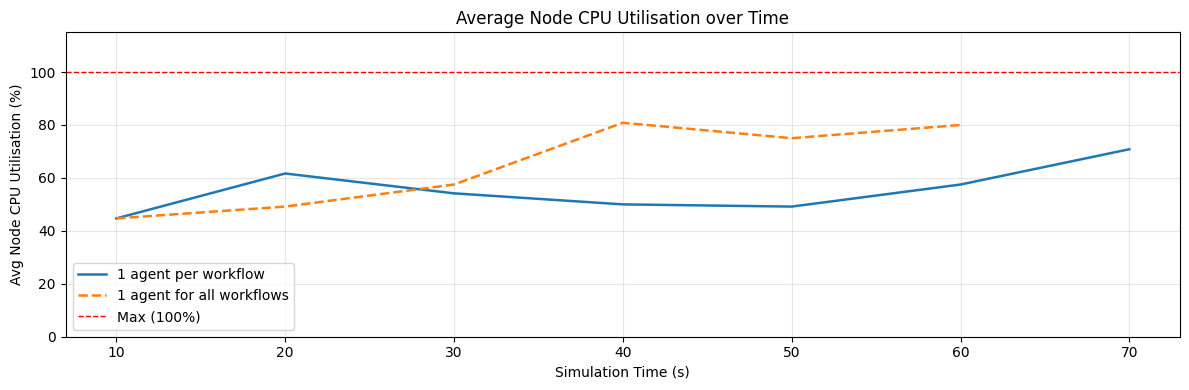

In [29]:
styles = ["-", "--", "-.", ":"]

fig, ax = plt.subplots(figsize=(12, 4))

for i, r in enumerate(results):
    disp   = r["dispatcher"]
    t      = disp.eval_times
    # average CPU across all nodes at each eval step
    node_ids = sorted(disp.node_cpu_hist.keys())
    if not node_ids:
        continue
    n_steps = min(len(disp.node_cpu_hist[nid]) for nid in node_ids)
    avg_cpu = np.mean([disp.node_cpu_hist[nid][:n_steps] for nid in node_ids], axis=0)
    ax.plot(t[:n_steps], avg_cpu, color=colors[i % len(colors)],
            linestyle=styles[i % len(styles)],
            label=r["label"], linewidth=1.8)

ax.axhline(100.0, color="red", linestyle="--", linewidth=1.0, label="Max (100%)")
ax.set_xlabel("Simulation Time (s)")
ax.set_ylabel("Avg Node CPU Utilisation (%)")
ax.set_title("Average Node CPU Utilisation over Time")
ax.set_ylim(0, 115)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 6 — Average agent reward over simulation time

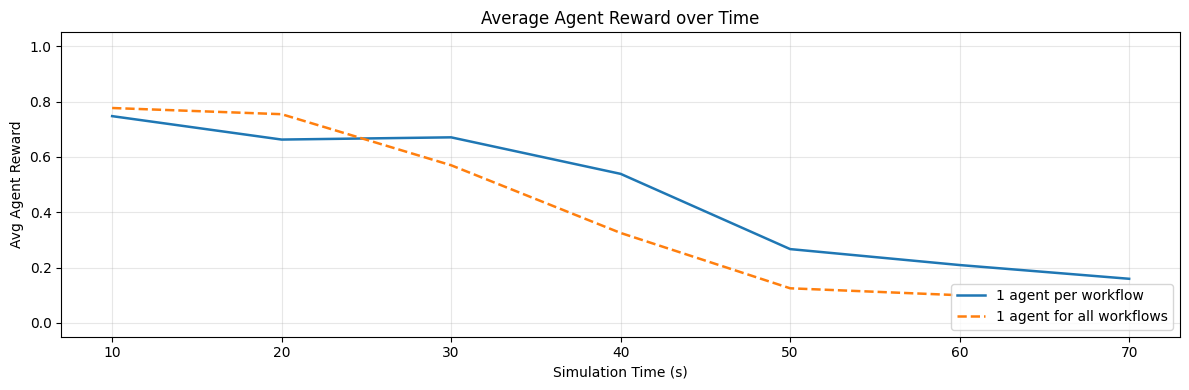

In [30]:
styles = ["-", "--", "-.", ":"]

fig, ax = plt.subplots(figsize=(12, 4))

for i, r in enumerate(results):
    disp       = r["dispatcher"]
    t          = disp.eval_times
    agent_names = list(disp.agent_reward_hist.keys())
    if not agent_names:
        continue
    n_steps = min(len(disp.agent_reward_hist[n]) for n in agent_names)
    avg_rew = np.mean([disp.agent_reward_hist[n][:n_steps] for n in agent_names], axis=0)
    ax.plot(t[:n_steps], avg_rew, color=colors[i % len(colors)],
            linestyle=styles[i % len(styles)],
            label=r["label"], linewidth=1.8)

ax.set_xlabel("Simulation Time (s)")
ax.set_ylabel("Avg Agent Reward")
ax.set_title("Average Agent Reward over Time")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()